# 5주차_데이터 탐색과 시각화 Ⅱ

- 공간 시각화

---

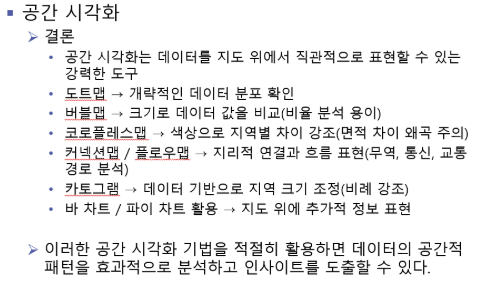

In [ ]:
# 필요한 패키지 설치
# !pip install folium

# folium은 Python에서 Leaflet.js 기반의 인터랙티브 지도(웹 기반)를 만들 수 있게 해주는 라이브러리. 
# 주로 **위치 기반 데이터 시각화(GIS)**를 할 때 많이 사용되며, 
# 복잡한 자바스크립트 없이도 지도를 웹에 표시하고, 마커나 원, 경로, 히트맵 등을 쉽게 추가할 수 있음.

# folium 모듈 및 구성요소 불러오기
import folium                        # folium의 전체 기능을 불러옴 (지도 생성, 마커 추가 등)
from folium import Marker           # 단일 위치 마커를 위한 클래스 (사용자 위치, 특정 지점 강조 등)
from folium import plugins          # 클러스터링, 히트맵 등 부가 기능들을 포함한 확장 패키지
from folium import GeoJson          # GeoJSON 형식의 경계 지도 데이터를 지도에 시각화할 수 있게 해주는 클래스
# 일반적인 데이터 분석/시각화 라이브러리 불러오기
import matplotlib.pyplot as plt     # 그래프 시각화를 위한 표준 라이브러리
import pandas as pd                 # 데이터프레임 기반의 데이터 처리 라이브러리
import numpy as np                  # 수치 계산, 배열 연산 등을 위한 라이브러리
# plotly 시각화 라이브러리 (3D 지오맵, 커넥션 맵 등 고급 시각화)
import plotly.graph_objects as go
# go는 Plotly의 저수준 시각화 객체들(Graph Objects)로 구성된 모듈로,
# 더 정밀한 제어가 필요한 경우에 사용됩니다 (예: Scattergeo, Choropleth 등)

plt.rcParams['figure.dpi'] = 300

In [3]:
# 서울 스타벅스 지점 데이터 불러오기
# https://www.kaggle.com/datasets/sewonghwang/starbucks-seoul
df=pd.read_csv("../../main/datasets/Starbucks_Seoul.csv")

# 지역 구분을 위한 json 파일 불러오기
geo="../../main/datasets/Seoul_Gu.json" 

# 데이터 샘플 확인
df.head()

# latitude 위도	longitude 경도

,name,address,gu_name,latitude,longitude
0,GS타워,서울특별시 강남구 논현로 508 (역삼동),강남구,37.501859,127.037278
1,SSG마켓도곡R,"서울특별시 강남구 언주로30길 57, 타워팰리스Ⅱ F 지하1층 (도곡동)",강남구,37.490298,127.054895
2,W-Mall,서울특별시 금천구 디지털로 188 (가산동),금천구,37.477305,126.887691
3,가든파이브,서울특별시 송파구 충민로 10 (문정동) 가든파이브툴,송파구,37.478232,127.119370
4,가락본동,서울특별시 송파구 송파대로30길 13 (가락동),송파구,37.494895,127.118785


In [4]:
df.shape

(521, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       521 non-null    object 
 1   address    521 non-null    object 
 2   gu_name    521 non-null    object 
 3   latitude   521 non-null    float64
 4   longitude  521 non-null    float64
dtypes: float64(2), object(3)
memory usage: 20.5+ KB


In [6]:
df.isnull().sum()

name         0
address      0
gu_name      0
latitude     0
longitude    0
dtype: int64

In [7]:
# 기본 지도 시각화 (서울의 위도, 경도 입력)

m = folium.Map(location=[37.541, 126.986], zoom_start=12)
# Folium의 지도 객체(folium.Map)를 생성하여 변수 m에 저장함
#
# ✔️ location=[37.541, 126.986]
#   - 지도 중심의 위도(latitude), 경도(longitude)를 지정함
#   - 여기서는 서울 중구 부근을 중심으로 설정 (서울 중심에 가까운 위치)
#
# ✔️ zoom_start=12
#   - 초기 확대 수준 설정 (기본값은 10, 1은 전 세계, 18은 건물 단위까지 확대)
#   - 12는 서울 시 전체를 한눈에 볼 수 있는 적당한 줌 레벨
#
# ※ 기본 지도 스타일은 OpenStreetMap이고, tiles 파라미터를 통해 다른 지도 스타일(CartoDB, Stamen 등)도 지정 가능함

m
# Jupyter Notebook 환경에서 지도 객체 m을 출력하면
# HTML iframe 형태로 인터랙티브 지도가 표시됨
# 마우스로 드래그하거나 스크롤로 확대/축소 가능

In [20]:
# 지도 형태 변경

m = folium.Map(
    location=[37.541, 126.986],
    # 지도 중심 좌표 지정: 서울 중심부 (위도 37.541, 경도 126.986)
    # 지도 초기 로딩 시 이 좌표를 중심으로 표시됨

    tiles='OpenStreetMap',
    # 사용할 타일(tile) 스타일 지정
    # 'OpenStreetMap'은 기본 지도 스타일이며, 가장 널리 사용됨
    # 다른 예시: 'CartoDB positron', 'Stamen Terrain', 'Stamen Toner', 'CartoDB dark_matter' 등

    # 이 옵션을 통해 지도 배경의 색상, 도로 스타일, 지형 정보 등을 변경할 수 있음

    attr='Map tiles by Stamen Design, under CC BY 3.0. Data by OpenStreetMap, under ODbL.',
    # 지도의 출처(저작권) 정보를 명시함
    # 웹 기반 시각화에서 타일 제공자(OpenStreetMap, Stamen 등)는 저작권 표시를 요구하는 경우가 많음
    # 해당 문자열은 지도 하단에 자동으로 출력되어 라이선스 요건을 만족시킴

    zoom_start=12
    # 초기 줌 레벨 설정 (1: 전 세계, 18+: 건물 수준)
    # 12는 도시 단위에서 주요 지역을 확인할 수 있는 수준 (서울 전체 확인 가능)
)

# -----------------------------------------------------------------

# tiles

# folium에서 사용할 수 있는 다양한 타일 스타일은 지도 시각화의 목적이나 분위기에 따라 선택할 수 있으며, 
# 대부분은 외부 타일 서버를 활용. 

# ✅ 주요 타일 스타일 목록

# 타일 이름	                tiles 값	                      특징
# OpenStreetMap	        'OpenStreetMap'	              기본값, 가장 일반적인 지도 스타일
# Stamen Terrain	        'Stamen Terrain'	       지형, 산맥, 강 등 강조 (등산, 지리용)
# Stamen Toner	        'Stamen Toner'	              흑백, 대비 강함 (분석용 지도 배경)
# Stamen Watercolor	    'Stamen Watercolor'	           수채화 느낌, 예술적인 배경
# CartoDB Positron	    'CartoDB positron'	          밝고 미니멀한 스타일 (데이터 시각화에 적합)
# CartoDB Dark_Matter	    'CartoDB dark_matter'	 어두운 배경, 야간 모드에 적합
# NASAGIBS Blue Marble	사용자 지정 (링크 필요)	         NASA 위성 이미지 기반 타일 (심미용)


# 원하는 좌표에 반경(radius) 표시 (남산 기준 좌표)
folium.CircleMarker(
    [37.5538, 126.9810],       # 위도(latitude), 경도(longitude) 좌표 입력 → 남산
    radius=50,                 # 반지름: 픽셀 단위 (지도 축척과 무관하게 화면상 크기 고정됨)
    popup='Laurelhurst Park', # 마커 클릭 시 표시될 팝업 텍스트
    color='#3246cc',           # 외곽선(테두리) 색상 설정 (진한 파란 계열)
    fill_color='#3246cc'       # 내부 채움 색상 설정 (테두리와 동일하게 설정됨)
).add_to(m)                    # 해당 마커를 지도 객체 m에 추가함


# 원하는 좌표에 포인트 마커 표시 (남산 동일 좌표)
folium.Marker(
    [37.5538, 126.9810],       # 위도(latitude), 경도(longitude) 좌표 입력
    popup='The Waterfront'     # 마커 클릭 시 표시될 팝업 텍스트
).add_to(m)                    # 해당 마커를 지도 객체 m에 추가함

    
m

In [22]:
# 서울 지도에 스타벅스 지점 수 시각화

# 지도 객체 생성 (width와 height를 올바르게 지정)
m = folium.Map(
    location=[37.541, 126.986],
    # 지도의 중심 좌표 → 서울 중심부 (위도 37.541, 경도 126.986)
    zoom_start=12,
    # 초기 확대 수준 → 도시 전체를 확인할 수 있는 적절한 줌 레벨
    width="100%",
    # 지도의 가로 크기 → HTML/CSS 기준, 브라우저 가로 폭의 100%로 설정
    height="100%"
    # 지도의 세로 크기 → 브라우저 세로 높이의 100%로 설정
)

# 스타벅스 매장들의 위치 좌표를 리스트 형태로 추출
locations = list(zip(df.latitude, df.longitude))
# df의 'latitude'(위도)와 'longitude'(경도)를 묶어 (위도, 경도) 튜플 리스트 생성
# 예: [(37.56, 126.97), (37.50, 127.01), ...]

# 마커 클러스터 객체 생성
cluster = plugins.MarkerCluster(
    locations=locations,
    # 각 매장의 위도/경도 좌표 리스트를 입력함
    popups=df["name"].tolist()
    # 각 마커 클릭 시 나타날 팝업 텍스트로 매장명을 지정함
)

# 생성한 클러스터 객체를 지도에 추가
m.add_child(cluster)
# 지도 m 위에 마커 클러스터를 시각적으로 반영함

# Jupyter Notebook 등에서 지도 출력
m
# 클러스터가 적용된 인터랙티브 지도 출력
# 줌을 축소하면 여러 마커가 하나로 묶이고, 확대하면 개별 마커로 풀림

In [24]:
# 서울 지도에 스타벅스 지점수 도드맵 시각화

m = folium.Map(
    location=[37.541, 126.986], 
    # 지도 중심 좌표 설정: 서울 중심부 (위도 37.541, 경도 126.986)
    zoom_start=12, 
    # 초기 줌 레벨 설정 (12 → 서울 전체가 보이는 수준)
    width="100%", 
    height="100%"
    # 지도 크기 설정 (화면 가로·세로 전체를 채우도록 설정)
)
# 지도 객체 생성 (m 변수에 저장)

locations = list(
    zip(
        df.latitude, 
        df.longitude
        )
)
# 스타벅스 매장 위치를 (위도, 경도) 튜플로 묶어 리스트 형태로 생성
# 예: [(37.51, 126.98), (37.52, 126.99), ...]


for i in range(len(locations)):
    folium.CircleMarker(
        location=locations[i],  # i번째 매장의 위도·경도 위치
        radius=1                # 반지름 1px의 아주 작은 원으로 표시
    ).add_to(m)                 # 지도에 마커를 추가함

m
# 완성된 지도 객체 출력
# 각 점이 서울 시내 스타벅스 매장 하나를 의미하며, 지리적 분포를 시각적으로 확인 가능함


In [26]:
# 서울 구 별 스타벅스 지점 수 집계 및 중심점 산출
df_m = df.groupby('gu_name').agg({  # 구 이름을 기준으로 그룹화
    'latitude': 'mean',       # 해당 구에 위치한 지점들의 위도 평균 → 구의 중심 위도 추정
    'longitude': 'mean',      # 해당 구의 경도 평균 → 구의 중심 경도 추정
    'name': 'count'           # 해당 구에 존재하는 스타벅스 지점 수를 count
}).reset_index()

# 그룹화 결과의 인덱스를 초기화하여 일반 데이터프레임 형태로 만듦
# 최종적으로 각 구별로 중심 좌표와 지점 수를 갖는 df_m 데이터프레임이 생성됨

# ┌──────────────────────┬────────────────────────────────────────────────┐
# │        구분          │                    설명                        │
# ├──────────────────────┼────────────────────────────────────────────────┤
# │ groupby() 결과       │ 그룹 키(예: gu_name)가 인덱스로 들어감          │
# │                      │ → Series/DataFrame의 인덱스 역할을 하게 됨     │
# ├──────────────────────┼────────────────────────────────────────────────┤
# │ reset_index() 효과   │ 그룹 키를 일반 컬럼으로 되돌림                  │
# │                      │ → 데이터프레임의 가시성과 접근성이 향상됨      │
# ├──────────────────────┼────────────────────────────────────────────────┤
# │ 실무 활용 측면       │ 이후 .merge(), .to_csv(), folium, plotly,      │
# │                      │ seaborn 등에서 **일반 컬럼**으로 있어야 오류 없이 처리됨 │
# └──────────────────────┴────────────────────────────────────────────────┘

df_m.head()

,gu_name,latitude,longitude,name
0,강남구,37.507603,127.044611,80
1,강동구,37.539914,127.137106,14
2,강북구,37.626866,127.026372,5
3,강서구,37.555716,126.841528,16
4,관악구,37.481759,126.944286,11


In [30]:
# 서울 구 별 스타벅스 지점 수 버블맵 시각화

# 기본 지도 생성
m = folium.Map(
    location=[37.541, 126.986],     # 서울 중심 좌표 (위도, 경도)
    tiles='Cartodb Positron',       # 밝고 미니멀한 배경지도
    zoom_start=11,                  # 줌 레벨: 서울 전체 구 단위가 잘 보이게 설정
    width="100%", height="100%"     # 지도 크기를 화면 전체로 지정 (Jupyter 출력 최적화)
)

# GeoJSON 파일을 적절한 인코딩으로 불러오기
import json
with open("../../main/datasets/Seoul_Gu.json", encoding="cp949") as f:
    geo = json.load(f)
# 서울시 구 단위 행정구역이 정의된 GeoJSON 파일 로드
# ⚠️ 한글 인코딩 파일이므로 'cp949' 또는 'euc-kr' 등 인코딩 지정이 중요함
# json.load()를 통해 파이썬 dict 형태로 불러옴

# 구별 구분선, 색상 설정
folium.Choropleth(
    geo_data=geo,         # 앞서 불러온 구 경계선 GeoJSON 데이터
    fill_color="gray"     # 구 구분 배경색 지정 (데이터 연동은 하지 않음)
).add_to(m)
# 지도에 서울의 구 경계를 회색 배경으로 그려서, 
# 이후 버블이 어떤 행정구역에 속하는지 식별 가능하게 만듦

# 버블맵 삽입
locations = list(zip(df_m.latitude, df_m.longitude))
# 구별 중심 좌표를 리스트 형태로 추출함 → 이후 CircleMarker 삽입에 사용

for i in range(len(locations)):
    row = df_m.iloc[i]  # i번째 구의 중심 좌표 및 스타벅스 지점 수 데이터 추출

    folium.CircleMarker(
        location=locations[i],         # 현재 구의 중심 좌표 지정
        radius=float(row.name / 2),    # 버블 크기 설정: 스타벅스 지점 수의 절반 값
                                       # ※ 너무 크거나 작을 경우 분모(2)를 조절 가능
        fill_color="blue",             # 원 내부 색상 지정
        color=None,                    # 테두리 없음으로 설정 (기본값일 경우 흰색 테두리 나올 수 있음)
        fill_opacity=0.6               # 투명도 조절 가능 (기본값 없음 → 필요시 추가 가능)
    ).add_to(m)
# 서울 지도 위에 각 구의 중심 좌표에 원을 그려 지점 수를 시각화함


# radius에 카운팅을 넣어줌
# 만약 원이 커서 겹치면 float(row.name/1)의 분모값을 조정

m
# 완성된 folium 지도 객체를 Jupyter Notebook 등에서 시각적으로 출력함

In [29]:
# 미국 실업률 정보의 코로플레스맵 시각화를 위한 데이터, json 불러오기
# https://www.kaggle.com/datasets/sewonghwang/us-unemployment

# ✅ 미국 실업률 정보 로딩
df2 = pd.read_csv("../../main/datasets/us_states_unemployment.csv")
# CSV 파일에는 미국 각 주(State)의 이름과 해당 주의 실업률(Unemployment)이 포함되어 있음
# 주요 컬럼 예시: State, Unemployment
# - 'State': 주 이름 (예: CA, NY, TX 등)
# - 'Unemployment': 실업률 수치 (예: 5.2%)

# ✅ 미국 주 경계 GeoJSON 파일 경로 지정
us_geo = '../../main/datasets/folium_us-states.json'
# 이 파일은 미국의 주별 경계선 정보를 담은 GeoJSON 포맷
# 각 주는 feature로 표현되며, 'id' 값이 주 약어(State 코드)와 일치해야 Choropleth와 연동됨

# ✅ 데이터 확인
df2.head()
# 데이터프레임의 앞부분을 출력하여 컬럼명이 올바르게 불러와졌는지, 실업률 수치가 포함되어 있는지 확인


,State,Unemployment
0,AL,7.1
1,AK,6.8
2,AZ,8.1
3,AR,7.2
4,CA,10.1


In [32]:
import folium

# 미국 지도 생성
m = folium.Map(
    location=[40, -98],             # 미국 중심 좌표 (위도 40, 경도 -98)
    zoom_start=4,                   # 줌 레벨: 미국 전체를 한눈에 보기 적절한 수준
    tiles="CartoDB positron"        # 밝고 깔끔한 스타일의 배경 지도 설정
)

# Choropleth 레이어 추가: 미국 주별 실업률 시각화
folium.Choropleth(
    geo_data=us_geo,                        # 미국 주 경계 정보 (GeoJSON 형식)
    data=df2,                               # 실업률 데이터프레임
    columns=['State', 'Unemployment'],     # 키: 주 이름, 값: 실업률
    key_on='feature.id',                   # GeoJSON에서 각 주를 식별하는 키 (feature.id)와 State 연결
    fill_color='YlGn',                     # 색상 팔레트: 낮은 값은 연노랑, 높은 값은 짙은 녹색
    fill_opacity=0.7,                      # 색상 투명도 (0~1)
    line_opacity=0.2,                      # 경계선 투명도
    legend_name='실업률 (%)'               # 범례 제목
).add_to(m)

# 지도 출력
m


In [33]:
import plotly.graph_objects as go
# Plotly의 시각화 객체(graph_objects)를 불러와 사용 준비함
# 고수준 시각화 구성 요소인 Figure, Scattergeo 등을 포함하는 모듈임

source_to_dest = zip(
    [37.541, 37.541, 37.541, 37.541, 37.541],
    # 출발지(서울)의 위도 값을 5개 복제하여 zip 구조에 맞게 나열함
    [35.6804, 38.9072, 14.5995, 48.8566, 55.7558],
    # 도착지(도쿄, 워싱턴, 마닐라, 파리, 모스크바)의 위도 값을 순서대로 지정함
    [126.986, 126.986, 126.986, 126.986, 126.986],
    # 출발지(서울)의 경도 값을 5개 복제하여 zip 구조에 맞게 나열함
    [139.7690, -77.0369, 120.9842, 2.3522, 37.6173]
    # 도착지들의 경도 값을 순서대로 지정함
)
# zip 함수를 통해 출발지 위도/경도와 도착지 위도/경도를 순서대로 묶어 튜플로 구성함

fig = go.Figure()
# Plotly Figure 객체를 생성하여 시각화 요소를 추가할 컨테이너 역할을 수행함

for a, b, c, d in source_to_dest:
    # source_to_dest에 정의된 튜플들을 순차적으로 반복하며 변수 a, b, c, d에 할당함
    # a: 출발지 위도, b: 도착지 위도, c: 출발지 경도, d: 도착지 경도 역할 수행함

    fig.add_trace(go.Scattergeo(
        lat=[a, b],
        # 연결선의 위도 좌표를 리스트로 지정하여 시작점과 끝점 정의함
        lon=[c, d],
        # 연결선의 경도 좌표를 리스트로 지정하여 시작점과 끝점 정의함
        mode='lines',
        # 점이 아닌 선으로 연결되도록 설정함
        line=dict(width=1, color="red"),
        # 선의 굵기를 1로, 색상을 빨간색으로 지정하여 시각적으로 강조함
        opacity=0.5
        # 선의 투명도를 0.5로 설정하여 중첩 시 식별이 가능하도록 조정함
    ))
    # 각 수도와 서울을 연결하는 선 형태의 지리 시각화(trace)를 Figure에 추가함

fig.update_layout(
    margin={"t": 0, "b": 0, "l": 0, "r": 0, "pad": 0},
    # 상단(top), 하단(bottom), 좌측(left), 우측(right)의 마진(여백)을 모두 0으로 설정함
    # pad는 내부 요소와 외부 가장자리 사이의 여백을 제어하며, 0으로 설정하여 여백을 제거함
    # 이 설정을 통해 시각화 요소가 출력 캔버스의 전체 공간을 최대한 활용하도록 함
    # 특히, 지도와 같은 시각화에서는 여백 없이 넓은 화면 제공으로 시인성을 향상시킴

    showlegend=False,
    # 범례(legend)를 화면에 출력하지 않도록 비활성화함
    # 본 시각화에서는 선의 의미가 동일(서울 → 해외 주요 수도)이므로 범례가 불필요함
    # 지도 상의 여백 확보 및 시각적 단순화를 목적으로 범례를 생략함

    geo=dict(
        showcountries=True
        # 지도에서 각 국가의 외곽 경계선을 표시하도록 설정함
        # 지도에 나타나는 선은 실제 국경선에 해당하며, 연결된 국가가 어디인지 명확하게 구분하도록 도움을 줌
        # Plotly의 Scattergeo에서 기본 지구 투영 위에 추가적인 국가 시각 정보를 제공함
    )
)
# 전체 레이아웃 구성요소를 설정하여 시각화 스타일과 인터페이스 요소를 제어함
# 특히 공간 활용 극대화, 시각적 복잡도 축소, 국가 구분의 시각적 명료화라는 목적에 최적화된 설정임


fig.show()
# 구성된 커넥션 맵(지리 기반 시각화)을 브라우저 또는 노트북 환경에서 출력함
